# `arbitragelab` Simple Example

This notebook uses the vendored `arbitragelab` package directly inside ARBS to show a minimal pair-trading workflow:

1. Load a local two-asset price series.
2. Estimate an OLS hedge ratio.
3. Construct the spread.
4. Run the Bollinger Bands trading rule on that spread.

Reference docs:

- [ArbitrageLab docs index](https://hudson-and-thames-arbitragelab.readthedocs-hosted.com/en/latest/index.html)
- [Hedge ratios](https://hudson-and-thames-arbitragelab.readthedocs-hosted.com/en/latest/hedge_ratios/hedge_ratios.html)
- [Z-score / Bollinger Bands trading](https://hudson-and-thames-arbitragelab.readthedocs-hosted.com/en/latest/trading/z_score.html)

In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (20, 12),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from arbitragelab.hedge_ratios import construct_spread
from arbitragelab.hedge_ratios.linear import get_ols_hedge_ratio
from arbitragelab.trading.z_score import BollingerBandsTradingRule


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "RVUtils" / "arbitragelab" / "tests" / "test_data" / "stock_prices.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the ARBS repo root from the current working directory.")


repo_root = find_repo_root(Path.cwd())
data_path = repo_root / "RVUtils" / "arbitragelab" / "tests" / "test_data" / "stock_prices.csv"
prices = pd.read_csv(data_path, parse_dates=["Date"], index_col="Date")[["EEM", "EWG"]]
prices

,EEM,EWG
Date,,
2008-01-02,49.273335,35.389999
2008-01-03,49.716667,35.290001
2008-01-04,48.223331,34.599998
2008-01-07,48.576668,34.630001
2008-01-08,48.200001,34.389999
...,...,...
2016-06-27,32.230000,22.920000
2016-06-28,33.180000,23.389999
2016-06-29,34.020000,23.709999


In [6]:
hedge_ratios, _, _, residuals = get_ols_hedge_ratio(
    price_data=prices,
    dependent_variable="EEM",
)

hedge_ratios


{'EEM': np.float64(1.0), 'EWG': np.float64(1.576625969585133)}

In [7]:
spread = construct_spread(
    price_data=prices,
    hedge_ratios=hedge_ratios,
    dependent_variable="EEM",
)
spread

Date
2008-01-02   -6.523458
2008-01-03   -5.922465
2008-01-04   -6.327925
2008-01-07   -6.021891
2008-01-08   -6.020165
                ...   
2016-06-27   -3.906268
2016-06-28   -3.697280
2016-06-29   -3.361800
2016-06-30   -3.557853
2016-07-01   -3.338221
Length: 2141, dtype: float64

In [8]:
strategy = BollingerBandsTradingRule(
    sma_window=20,
    std_window=20,
    entry_z_score=2.5,
    exit_z_score_delta=3,
)

strategy.update_spread_value(spread.iloc[0])
for timestamp, value in spread.iloc[1:].items():
    strategy.update_spread_value(value)
    should_trade, side = strategy.check_entry_signal()
    if should_trade:
        strategy.add_trade(start_timestamp=timestamp, side_prediction=side)
    strategy.update_trades(update_timestamp=timestamp)

trade_summary = pd.DataFrame(strategy.closed_trades).T
trade_summary.index.name = "entry_time"
trade_summary[["t1", "pt", "start_value", "end_value", "side", "initial_z_score"]]

,t1,pt,start_value,end_value,side,initial_z_score
entry_time,,,,,,
2008-06-25,2008-07-09 00:00:00,-0.878447,-1.611403,-3.213685,-1,2.603204
2008-06-30,2008-07-09 00:00:00,-0.878447,-1.175868,-3.213685,-1,2.507647
2009-04-27,2009-05-01 00:00:00,0.466262,0.687282,1.625176,1,-2.694637
2009-08-17,2009-09-03 00:00:00,0.495095,3.46543,3.79909,1,-2.529994
2009-10-05,2009-10-23 00:00:00,-0.162862,4.700647,4.308405,-1,2.870066
2010-04-05,2010-04-16 00:00:00,-0.693106,8.514306,7.600798,-1,2.565763
2010-04-06,2010-04-16 00:00:00,-0.693106,8.84927,7.600798,-1,2.667635
2010-05-10,2010-05-17 00:00:00,-0.82839,9.107919,7.843611,-1,2.58796
2010-05-20,2010-05-27 00:00:00,0.575424,6.072208,8.184992,1,-3.028976


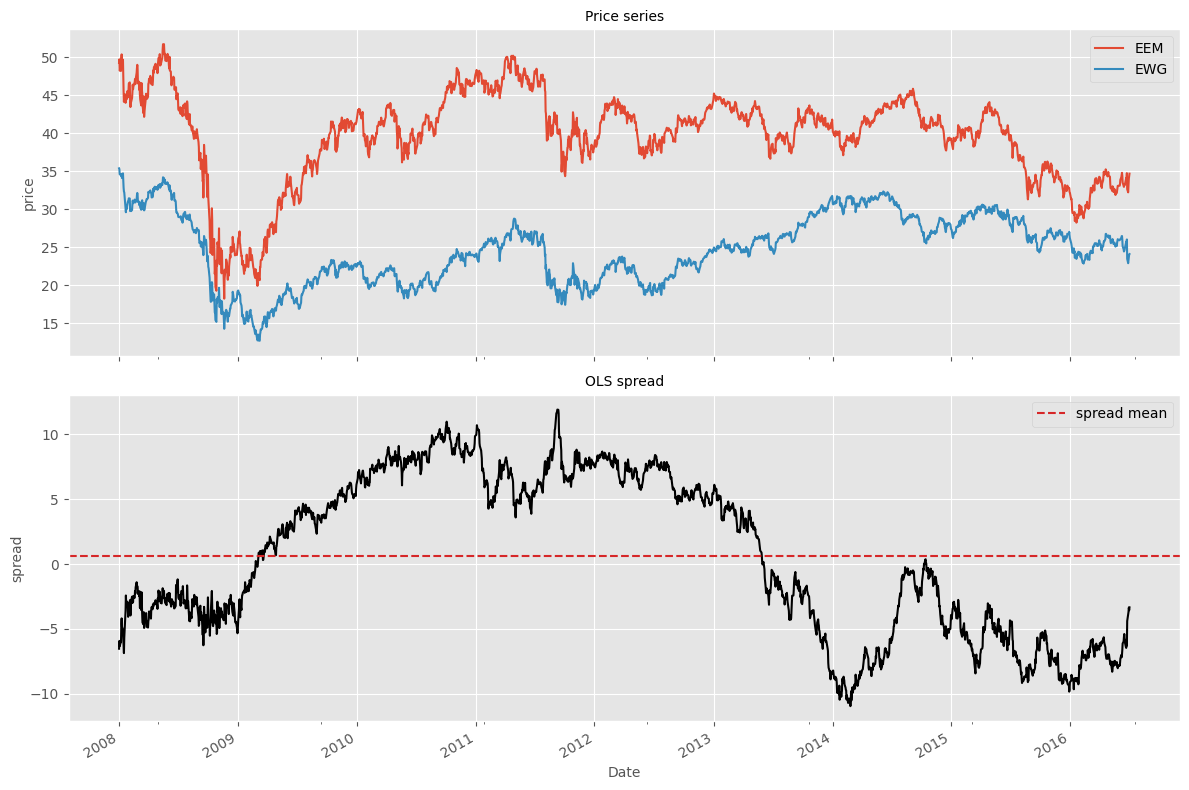

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

prices.plot(ax=axes[0], title="Price series")
axes[0].set_ylabel("price")

spread.plot(ax=axes[1], color="black", title="OLS spread")
axes[1].axhline(spread.mean(), color="tab:red", linestyle="--", label="spread mean")
axes[1].set_ylabel("spread")
axes[1].legend()

plt.tight_layout()